# Stellar mass estimation for the GLADE+ galaxies

This notebook contains the stellar mass estimation for the GLADE+ galaxies with four IR-based methods.

The code was written by Mária Pálfi (marika97@student.elte.hu).

In [1]:
# importing useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

# Reading the catalogue

In [2]:
# reading the file to 'data' pandas dataframe
data = pd.read_csv( '../GLADE+.txt', header = None, delimiter = ' ', 
                   usecols=[0,4,5,7,8,9,20,21,22,23,27,31,32,33,37],
                   names=[ "ID", "2MASS","wiseX", "type", "ra", "dec", 
                          "W1", "W1_err", "W2", "W2_err", "z", "z_err", "dL", "dL_err","gal_type"],
                   low_memory = False )
print( 'dataframe with the necessary columns:\n' )
data

dataframe with the necessary columns:



,ID,2MASS,wiseX,type,ra,dec,W1,W1_err,W2,W2_err,z,z_err,dL,dL_err,gal_type
0,1,12505314+4107125,J125053.14+410712.7,G,192.721451,41.120152,5.611000,NaN,6.120000,NaN,0.000991,0.000029,4.392418,NaN,1.0
1,2,12352642+1429467,J123526.45+142946.9,G,188.860123,14.496320,9.416000,NaN,9.306000,NaN,0.004120,0.000119,15.876007,3.263033,1.0
2,3,17492651+7008396,J174926.45+700840.8,G,267.360474,70.144341,10.180000,NaN,10.102000,NaN,0.001000,0.000029,12.446600,0.987781,1.0
3,4,12280389+0948130,J122803.90+094813.3,G,187.016220,9.803620,8.476000,NaN,8.504000,NaN,0.003557,0.000103,11.461371,2.484465,0.0
4,5,NaN,J122928.05+084500.8,G,187.367000,8.749890,9.784000,NaN,9.706000,NaN,0.004139,0.000120,15.180920,3.321809,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23181753,23181754,NaN,NaN,Q,359.999118,28.954734,17.728901,NaN,16.535843,NaN,2.452000,0.113916,20403.464630,NaN,NaN
23181754,23181755,NaN,NaN,Q,359.999303,34.720842,16.933657,NaN,15.875454,NaN,3.109000,0.135597,27158.368406,NaN,NaN
23181755,23181756,NaN,NaN,Q,359.999615,3.268586,14.833991,NaN,13.702355,NaN,1.232962,0.073688,8792.439985,NaN,NaN
23181756,23181757,NaN,NaN,Q,359.999759,20.721079,16.979166,NaN,16.091722,NaN,2.009865,0.099325,16022.500633,NaN,NaN


## Adding K magnitudes

Cappellari used the *k_m_ext*, but we have *k_m_k20fe*.

https://irsa.ipac.caltech.edu/applications/2MASS/PubGalPS/XSC_key.html

I downloaded the 2MASS data from https://irsa.ipac.caltech.edu/cgi-bin/Gator/nph-dd.

In [3]:
twomass = pd.read_csv( '../2mass.csv' )
dic = { '2MASS': twomass.designation, 'k_m_ext': twomass.k_m_ext, 
       'k_msig_ext': twomass.k_msig_ext}
twomasswork = pd.DataFrame( dic )

data = pd.merge(data, twomasswork, on=['2MASS'], how='left')
print( 'merged dataframe:\n' )
data.head()

merged dataframe:



,ID,2MASS,wiseX,type,ra,dec,W1,W1_err,W2,W2_err,z,z_err,dL,dL_err,gal_type,k_m_ext,k_msig_ext
0,1,12505314+4107125,J125053.14+410712.7,G,192.721451,41.120152,5.611,NaN,6.120,NaN,0.000991,0.000029,4.392418,NaN,1.0,5.106,0.016
1,2,12352642+1429467,J123526.45+142946.9,G,188.860123,14.496320,9.416,NaN,9.306,NaN,0.004120,0.000119,15.876007,3.263033,1.0,7.115,0.031
2,3,17492651+7008396,J174926.45+700840.8,G,267.360474,70.144341,10.180,NaN,10.102,NaN,0.001000,0.000029,12.446600,0.987781,1.0,7.296,0.021
3,4,12280389+0948130,J122803.90+094813.3,G,187.016220,9.803620,8.476,NaN,8.504,NaN,0.003557,0.000103,11.461371,2.484465,0.0,7.294,0.024
4,5,NaN,J122928.05+084500.8,G,187.367000,8.749890,9.784,NaN,9.706,NaN,0.004139,0.000120,15.180920,3.321809,1.0,NaN,NaN


Freeing memory:

In [4]:
del twomass
del twomasswork

## Filtration

In [5]:
# We need only the galaxies, therefore we filtrate the quasars ('Q'):
data_new = copy.deepcopy( data[ data.type != 'Q' ] )
print('Length with galaxies only:', data_new.shape[0])
# we need galaxies having luminosity distance:
data_new = data_new[ ~np.isnan(data_new.dL) ] 
print( 'Length with known luminosty distance:', data_new.shape[0])
# Kettlety et al. also filtrated the z < 0.003 galaxies,
# because they may be stellar contamintaion.
data_new = data_new[data_new.z > 0.003 ]
print( 'Number of galaxies with z > 0.003:', len( data_new ))

# Then we filtrate out the nan Kmag values, because it is essential 
# to the Cappellari's method (see below), but we save into a 
# new dataframe:
data_new2 = data_new[ ~np.isnan(data_new.k_m_ext) ]
print('Length with Kmag:', data_new2.shape[0])

# We need the WISE magnitude (from the original dataframe):
data_new = data_new[ ~np.isnan(data_new.W1) ]
print('Length with W1:', data_new.shape[0])
data_new = data_new[ ~np.isnan(data_new.W2) ]
print('Length with W2:',data_new.shape[0])

# Let's see how many galaxies have both WISE and Ks magnitudes:
data_new3 = copy.deepcopy( data_new[ ~np.isnan(data_new.k_m_ext) ] )
print('Length with both magnitudes:', data_new3.shape[0])
del data_new3 # freeing memory

Length with galaxies only: 22431348
Length with known luminosty distance: 21884622
Number of galaxies with z > 0.003: 21880121
Length with Kmag: 1003386
Length with W1: 21779151
Length with W2: 21747171
Length with both magnitudes: 970908


## Estimating the stellar mass via Cluver's method

According to Cluver et al. 2014 (Cluver, M. E., et al. 2014, The Astrophysical Journal, 782, 90
doi:10.1088/0004-637X/782/2/90), we can estimate the stellar mass with the following equation:

$$lg (M_\ast /L_{W1} ) = −1.96(W1 − W2 ) − 0.03,$$ 

where

$$L_{W1} (L_\odot) = 10^{−0.4(M −M_\odot )},$$  

$$M_\odot = 3.24$$ 

$M$ is the absolute magnitude measured in the W1 filter, $W1-W2$ is rest-frame color.

I calculate the absolute magnitude:

$$m-M = -5+5 \lg d,$$ 

$$M = m+5-5 \lg d,$$

where $m$ is the apparent magnitude, $d$ is the distance (luminosity distance).


According to Cluver et al. 2014. the magnitudes are in the Vega system, and the WISE magnitudes are also in the Vega system (http://wise2.ipac.caltech.edu/docs/release/allsky/expsup/sec4_4h.html#conv2flux).

The WISExSCOS catalog (Bilicki et al. 2016. (The Astrophysical Journal Supplement Series, 225:5 (24pp), 2016 July, doi:10.3847/0067-0049/225/1/5)) has also WISE magnitudes in Vega system.


The estimation is the best at $ z < 0.15 $. I did not find any other validity limit in this article.


### K correction

With the K correction of the absolute magnitude we can take into account the shifting of the band because of the expansion of the Universe. This means that we measure the light emitted in an 'x' band in other 'y' band. 

According to Hogg et al. 2002. (https://arxiv.org/abs/astro-ph/0210394):

$$m_R = M_Q + DM + K_{QR},$$

where $m_R$ is the apparent magnitude measured in the band $R$, $M_Q$ is the absolute magnitude emitted in band $Q$, $K_{QR}$ is the K correction and DM is the distance modulus:

$$DM = 5 \cdot \lg \frac{D_L}{10 ~pc},$$

where $D_L$ is the luminosity distance.

I tried to make the K correction according to the articles (Cluver et al. 2014, Ducoin et al. 2019, but I cannot reach the templates they used, the links do not work). 

I find a thesis giving a simple approximation for the K correction of WISE bands. According to *Affadi Ikechukwu Patrick*'s thesis, *A New Method of Mapping Cosmic Flow Fields: Evaluating the Suitability of the Infrared bands
Tully-Fisher Relation for ZoA Work* the K correction for the WISE bands:

$$K_{W1} = −2.5854 z, $$

$$K_{W2} = −2.9358 z, $$

where $z$ is the redshift.

Later I would like to give a more precise correction.

### Another method: Kettlety et al. 2018.

$$K_ {W1} = - 7.1 \lg( 1 + z )$$

### Absolute magnitude:

$$M = m+5-5 \lg d - K$$

In [6]:
# absolute magnitude in the W1 band without K correction:
M1_wKc = data_new.W1 + 5 - 5 * np.log10( data_new.dL*1e6 )
print( 'absolute magnitude in the W1 band without K correction:' )
print( M1_wKc.iloc[0:5] )

# K corrected absolute W1 magnitudes:
M1 = M1_wKc + 2.5854 * data_new.z 
print( '\nK corrected absolute W1 magnitudes:' )
print( M1.iloc[0:5] )

# K correction for W1 magnitudes according to Kettlety:
M1_Kettlety = M1_wKc + 7.1 * np.log10(1+data_new.z) 
print( '\nK corrected absolute W1 magnitudes according to Kettlety:' )
print( M1_Kettlety.iloc[0:5] )


# absolute magnitude in the W2 band without K correction:
M2_wKc = data_new.W2 + 5 - 5 * np.log10( data_new.dL*1e6 )
print( '\nabsolute magnitude in the W2 band without K correction:' )
print( M2_wKc.iloc[0:5] )

# K corrected absolute W2 magnitudes:
M2 = M2_wKc + 2.9358 * data_new.z 
print( '\nK corrected absolute W2 magnitudes:' )
print( M2.iloc[0:5] )

absolute magnitude in the W1 band without K correction:
1   -21.587706
3   -21.820183
4   -21.122490
5   -20.092803
6   -21.407693
dtype: float64

K corrected absolute W1 magnitudes:
1   -21.577056
3   -21.810987
4   -21.111790
5   -20.084220
6   -21.396472
dtype: float64

K corrected absolute W1 magnitudes according to Kettlety:
1   -21.575030
3   -21.809235
4   -21.109755
5   -20.082583
6   -21.394339
dtype: float64

absolute magnitude in the W2 band without K correction:
1   -21.697706
3   -21.792183
4   -21.200490
5   -20.106803
6   -21.332693
dtype: float64

K corrected absolute W2 magnitudes:
1   -21.685612
3   -21.781741
4   -21.188340
5   -20.097057
6   -21.319951
dtype: float64


### Calculating $L_{W1}$ :

$$L_{W1} (L_\odot) = 10^{−0.4(M −M_\odot )}, $$

$$M_\odot = 3.24^\text{m}$$

In [7]:
M_sun = 3.24

L_W1 = 10**( -0.4 * ( M1 - M_sun ) )
L_W1.iloc[0:5]

1    8.449330e+09
3    1.048081e+10
4    5.504478e+09
5    2.136426e+09
6    7.154655e+09
dtype: float64

### Mass - luminosity ratio:

$$TM = −1.96(W1 − W2 ) − 0.03$$

In [8]:
TM = -1.96*( M1 - M2 ) - 0.03
TM.iloc[0:5]

1   -0.242771
3    0.027323
4   -0.180038
5   -0.055160
6    0.119981
dtype: float64

### Stellar mass:

$$lg (M_\ast /L_{W1} ) = TM$$

$$M_\ast / L_{W1} = 10^{TM}$$

$$M_\ast = 10^{TM} L_{W1}$$

In [9]:
print( 'The stellar mass:' )
M_Cluver = L_W1 * 10**TM
M_Cluver.iloc[0:5]

The stellar mass:


1    4.831161e+09
3    1.116137e+10
4    3.636457e+09
5    1.881603e+09
6    9.431257e+09
dtype: float64

In [10]:
limit_pow = 5
print( 'How many galaxies have stellar mass less than 10^' + str(limit_pow) + '?')
( M_Cluver < 10**limit_pow ).sum()

How many galaxies have stellar mass less than 10^5?


np.int64(8)

#### Histogram of the stellar mass:

In [11]:
def hist_form( ytext = '$\lg M_{*}$ [$M_\odot$]', logscale = True ):
    fig = plt.figure( figsize = (8, 5), dpi = 100 )
    plt.xlabel( ytext, fontsize = 25 )
    plt.ylabel( 'Frequency', fontsize = 25 )
    if logscale == True:
        plt.yscale('log')
        plt.ylim([1e-1, 1e8])
    plt.xticks( fontsize = 18 )
    plt.yticks( fontsize = 18 )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )

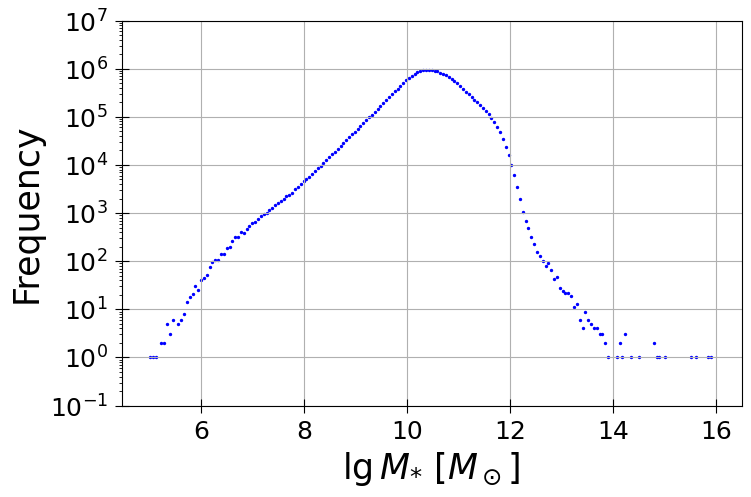

In [12]:
# form the figure:
hist_form()
plt.ylim( 1e-1, 1e7)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Cluver), np.linspace(5, 16, 200) )
plt.scatter( bins[:-1], freq,  marker = 'o', lw = 1, s = 2, color = 'blue' )
plt.grid()

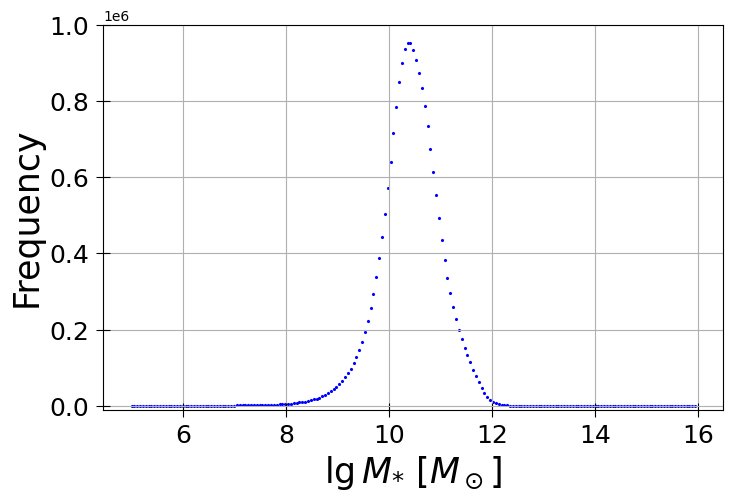

In [13]:
# form the figure:
hist_form()
plt.yscale( 'linear' )
plt.ylim(-1e4, 1e6)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Cluver), bins=np.linspace(5, 16, 200) )
plt.scatter( bins[:-1], freq,  marker = '*', lw = 1, s = 2, color = 'blue' ) 
plt.grid()

## Error estimation

### Function for error propagation

We approximate the error with the standard deviation, $\sigma_f$, calculated from 

$$\sigma_f^2 \approx \sum_{i=1}^n \left|\frac{\partial f}{\partial x_i}\right|^2 \sigma_i^2 + 2 \cdot \sum_{j=1}^n \sum_{k>j}^n \frac{\partial f}{\partial x_j} \frac{\partial f}{\partial x_k} \sigma_j \sigma_k \rho_{jk},
$$

where $f$ is a function of $x_i$ variables with $\sigma_i$ uncertainty, $\rho$ is the correlation coefficient of $j$ and $k$ variable.

In [14]:
def error_estimator_var( derivative, var, size, N ):
    summa_var = np.zeros( size )
    for i in range( 0, N ):
        summa_var += derivative[i]**2 * var[i]**2
    return summa_var
        
        
def error_estimator_covar( derivative, var, corr_coef, size, N ):
    summa_covar = np.zeros( size )
    for j in range( 0, N ):
        for k in range( j+1, N ):
            summa_covar += derivative[j] * derivative[k] * var[j] * var[k] * corr_coef[j][k]
    return 2 * summa_covar

### Plotting functions

In [15]:
def comp_hist( rel_err, rel_corr_err ):
    fig, ax = plt.subplots(figsize = (8, 5), dpi = 100)
    plt.xlabel( 'Relative error of stellar mass [%]', fontsize = 20 )
    plt.ylabel( 'Relative frequency [%]', fontsize = 20 )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )
    plt.xticks(fontsize = 18 )
    plt.yticks( fontsize = 18 )
    plt.xlim( 0, 200)
    plt.yscale( 'linear' )
    plt.xscale('linear')
    plt.autoscale()
    #ax.set_xticks(np.arange( 0, 110, 20) )
    #ax.set_xticklabels(np.arange(0, 110, 20))

    freq, bins = np.histogram( rel_err*100,  bins=np.linspace(0, 500, 101), density = True )
    plt.plot( bins[:-1], freq*(bins[1]-bins[0])*100, lw = 1, label = 'without correlation', color = 'purple' )

    freq, bins = np.histogram( rel_corr_err*100,  bins=np.linspace(0, 500, 101), density = True )
    plt.plot( bins[:-1], freq*(bins[1]-bins[0])*100, lw = 1, label = 'with correlation', color = 'orange' )
    plt.grid()
    plt.legend(fontsize = 20)

In [16]:
def comp_plot( rel_err, rel_corr_err ):
    # form the figure:
    fig = plt.figure( figsize = (8,5), dpi = 100 )
    plt.xlabel( 'Relative error without correlation [%]', fontsize = 20 )
    plt.ylabel( 'Relative error with correlation [%]', fontsize = 20 )
    plt.xticks( fontsize = 18 )
    plt.yticks( fontsize = 18 )
    plt.tick_params( length=10, direction = 'inout', pad = 5 )

    plt.scatter( rel_err, rel_corr_err, s = 0.01, color = 'forestgreen' )

    # draw a 45 degree straight line:
    xval = np.linspace( min(rel_err), max(rel_err), len(rel_err) )
    plt.plot( xval, xval, 'black', lw = 0.5)

    plt.grid()

If there is no magnitude error, I use the estimated relative errors from *Missing_error_estimation_rel.ipynb*.

In [17]:
data_new.fillna( {'W1_err': 0.005*data_new.W1}, inplace=True )
print( 'How many nan errors have remained?', np.sum(np.isnan(data_new['W1_err'])) )

How many nan errors have remained? 0


In [18]:
data_new.fillna( {'W2_err': 0.01*data_new.W2}, inplace=True )
print( 'How many nan errors have remained?', np.sum(np.isnan(data_new['W2_err'])) )

How many nan errors have remained? 0


If there is no luminosity distance error, I use the ones calculated from the redshift.

In [19]:
dle = pd.read_csv( '../dist_errs.txt', header = None, delimiter = ' ', names = ['dl', 'edl'] )
dle[:5]

,dl,edl
0,4.392418,0.127479
1,18.310840,0.532731
2,4.433422,0.128670
3,15.802501,0.459550
4,18.396048,0.535217


In [20]:
data_new.fillna( {'dL_err':dle['edl']}, inplace=True )
print( 'How many nan errors have remained?', np.sum(np.isnan(data_new['dL_err'])) )

How many nan errors have remained? 0


The terms in the error propagation:

In [21]:
log = np.log(10)*M_Cluver

Cluver_der_W1 = -2.36*log
Cluver_der_W2 = 1.96*log
Cluver_der_d = 2*M_Cluver/data_new.dL
Cluver_der_z = -0.345416*log

Cluver_der = [ Cluver_der_W1, Cluver_der_W2, Cluver_der_d, Cluver_der_z ]
Cluver_var = [(data_new.W1_err), (data_new.W2_err), (data_new.dL_err), (data_new.z_err)]
Cluver_var_err = error_estimator_var( Cluver_der, Cluver_var, len(data_new), 4 )

Correlation coefficients:

In [22]:
corr_coef_W1 = [data_new.W1.corr(data_new.W1), data_new.W1.corr(data_new.W2),
                data_new.W1.corr(data_new.dL), data_new.W1.corr(data_new.z)]
corr_coef_W2 = [data_new.W2.corr(data_new.W1), data_new.W2.corr(data_new.W2),
                data_new.W2.corr(data_new.dL), data_new.W2.corr(data_new.z)]
corr_coef_d = [data_new.dL.corr(data_new.W1), data_new.dL.corr(data_new.W2),
                data_new.dL.corr(data_new.dL), data_new.dL.corr(data_new.z)]

Cluver_corr_coef = [ corr_coef_W1, corr_coef_W2, corr_coef_d ]

In [23]:
Cluver_covar_err = error_estimator_covar(Cluver_der, Cluver_var, Cluver_corr_coef, len(data_new), 4 )

Cluver_err = np.sqrt(Cluver_var_err)
Cluver_err_corr = np.sqrt(Cluver_var_err + Cluver_covar_err)

rel_err_M_Cluver = np.sqrt(Cluver_var_err)/M_Cluver
rel_corr_err_M_Cluver = np.sqrt(Cluver_var_err + Cluver_covar_err)/M_Cluver

(0.0, 250.0)

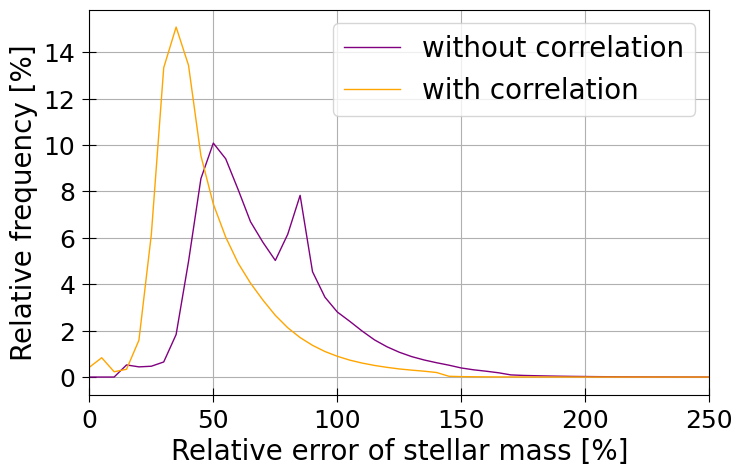

In [24]:
comp_hist( rel_err_M_Cluver, rel_corr_err_M_Cluver )
plt.xlim(0,250)

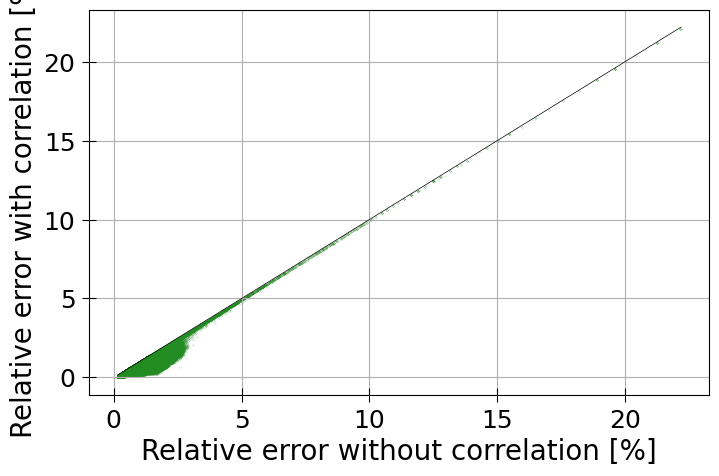

In [25]:
comp_plot( rel_err_M_Cluver, rel_corr_err_M_Cluver )

In [26]:
int((rel_corr_err_M_Cluver > 1).sum())

949708

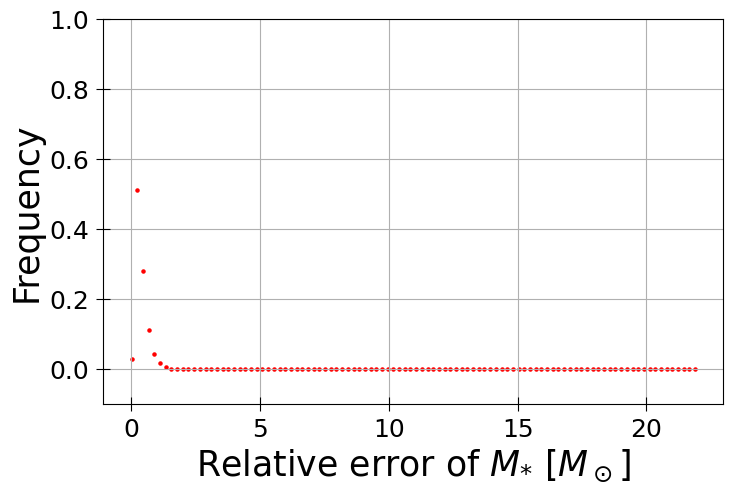

In [27]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.1, 1)

freq, bins = np.histogram( rel_corr_err_M_Cluver,  bins=100 )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.W1)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

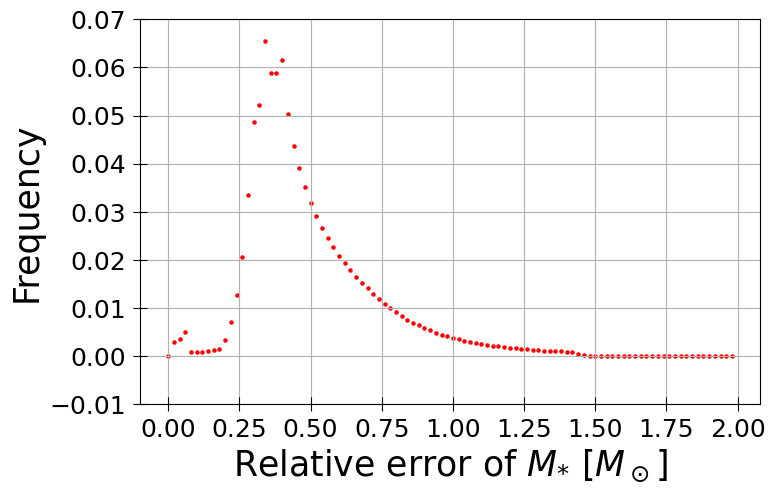

In [28]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.01, 0.07)

freq, bins = np.histogram( rel_corr_err_M_Cluver,  bins=np.linspace(0, 2, 101) )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.W1)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

Mean and median error:

In [29]:
print( np.mean(rel_corr_err_M_Cluver), np.median(rel_corr_err_M_Cluver) )

0.5083426657634196 0.4437498109597267


In [30]:
print( np.mean(rel_err_M_Cluver), np.median(rel_err_M_Cluver) )

0.7430424355383904 0.6864528943391126


How many galaxies have stellar mass from this method?

In [31]:
len(M_Cluver)

21747171

## Estimaing the stellar mass via Kettlety's method
Kettlety et al. 2018. (MNRAS 473, 776–783 (2018), doi:10.1093/mnras/stx2379)

### For passive galaxies:
$$M_*/L_{W1} = 0.65 \pm 0.07$$

$$M_* = 0.65 \cdot L_{W1}$$

This is best for z $\leq$ 0.15.

$$L_{W1} (L_{Sun}) = 10^{−0.4(M −M_{Sun} )},$$  

$$M_{Sun} = 3.24$$ 

$M$ is the absolute magnitude measured in the W1 filter.

(It was first published in Norris et al. (2014) (Norris M. A., Meidt S., van de Ven G., Schinnerer E, Groves B., Querejeta M., 2014, ApJ, 797, 55).)

I calculate the absolute magnitude:

$$m-M = -5+5 \lg d,$$ 

$$M = m+5-5 \lg d,$$

where $m$ is the apparent magnitude, $d$ is the distance (luminosity distance).

#### K correction
With the K correction of the absolute magnitude we can take into account the shifting of the band because of the expansion of the Universe. This means that we measure the light emitted in 'x' band in 'y' band. 

According to Hogg et al. 2002. (https://arxiv.org/abs/astro-ph/0210394):

$$m_R = M_Q + DM + K_{QR},$$

where $m_R$ is the apparent magnitude measured in band $R$, $M_Q$ is the absolute magnitude emitted in band $Q$, $K_{QR}$ is the K correction and DM is the distance modulus:

$$DM = 5 \cdot \lg \frac{D_L}{10 ~pc},$$

where $D_L$ is the luminosity distance.

In Kettlety et al. 2018.:

$$K_ {W1} = - 7.1 \lg( 1 + z )$$

The **stellar mass** can be calculated from the WISE W1 magnitude (m) as:
$$M_* = 0.65 \cdot 10^{-0.4[m+5-5\lg d + 7.1\lg(1+z)-3.24]}$$


### For active galaxies:
$$ \lg(M_*/L_{W1}) = -0.4 \pm 0.2$$

$$ M_* = 10^{-0.4} \cdot L_{W1}$$


### The uncertainty:
$$\Delta M_*(a,m,d,z) = M_* \cdot \sqrt{ \left(\frac{\Delta a}{a} \right)^2 + |0.4 \cdot \ln(10)|^2 \cdot \Delta m^2+4\cdot \left( \frac{\Delta d}{d}\right)^2 + (0.4\cdot 0.71)^2 \cdot \left( \frac{\Delta z}{|1+z|}\right)^2},$$
where $\Delta a = 0.07$.

In [32]:
filt_passive = data_new.gal_type == 0
filt_active = data_new.gal_type != 0

In [33]:
print( np.sum(filt_active), np.sum(filt_passive) )

20818981 928190


In [34]:
M_sun = 3.24

print( '$L_{W1}$ luminosity:' )
L_W1_Kettlety = 10**( -0.4 * ( M1_Kettlety - M_sun ) )
print( L_W1_Kettlety.iloc[0:5] )

print( '\nThe stellar mass:' )
# stellar mass for passive galaxies:
M_Kettlety = 0.65*L_W1_Kettlety[ filt_passive ]
# stellar mass for active galaxies:
M_Kettlety_active = 10**(-0.4)*L_W1_Kettlety[ filt_active ]
M_Kettlety = pd.concat( [ M_Kettlety, M_Kettlety_active ] )
M_Kettlety.iloc[0:5]

$L_{W1}$ luminosity:
1    8.433579e+09
3    1.046391e+10
4    5.494170e+09
5    2.133208e+09
6    7.140614e+09
dtype: float64

The stellar mass:


3      6.801542e+09
6      4.641399e+09
7      3.482201e+09
18     2.019498e+08
189    2.593296e+10
dtype: float64

In [35]:
# Is there any too small stellar mass?
print( np.sum( M_Kettlety < 1e5 ) )

0


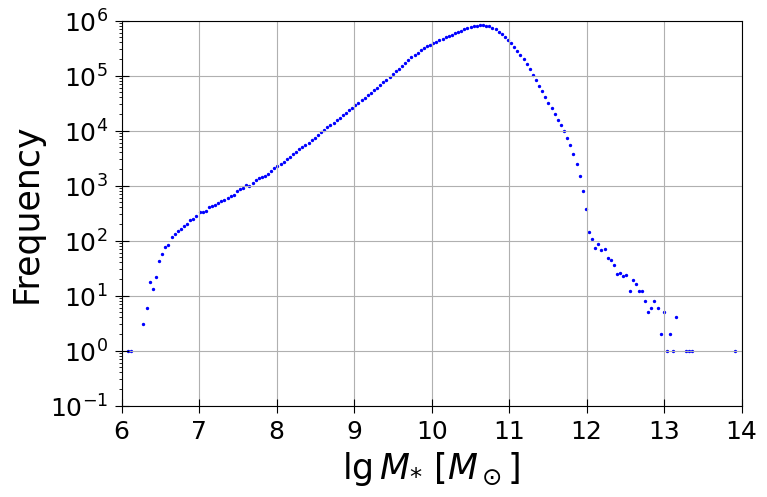

In [36]:
# form the figure:
hist_form()
plt.ylim( 1e-1, 1e6)
plt.xlim(6, 14)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Kettlety), np.linspace(6, 14, 200) )
plt.scatter( bins[:-1], freq,  marker = 'o', lw = 1, s = 2, color = 'blue' )
plt.grid()

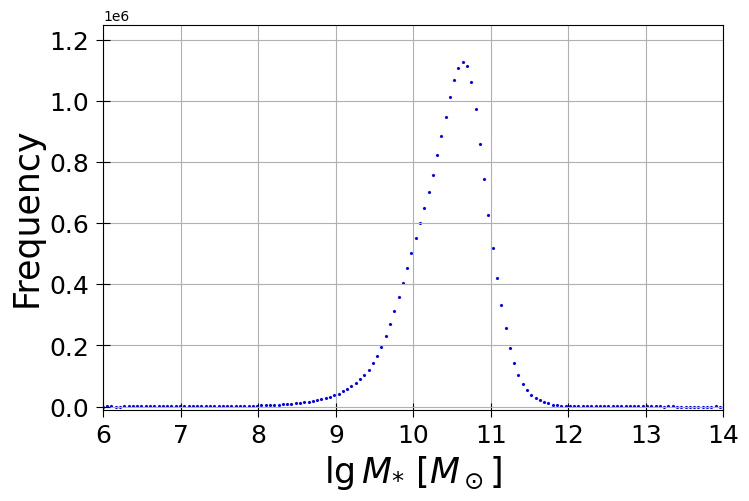

In [37]:
# form the figure:
hist_form()
plt.yscale( 'linear' )
plt.ylim(-1e4, 1.25e6)
plt.xlim(6, 14)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Kettlety), bins=np.linspace(5, 16, 200) )
plt.scatter( bins[:-1], freq,  marker = '*', lw = 1, s = 2, color = 'blue' ) 
plt.grid()

**Error estimation**

The terms in the error propagation:

In [38]:
data_new_passive = data_new[ filt_passive ]
data_new_active = data_new[ filt_active ]
M_Kettlety_passive = M_Kettlety[ filt_passive ]

In [39]:
log_passive = np.log(10)*M_Kettlety_passive
log_active = np.log(10)*M_Kettlety_active

Kettlety_der_a_passive = M_Kettlety_passive/0.65
Kettlety_der_a_active = log_active
Kettlety_der_m_passive = -0.4 * log_passive
Kettlety_der_m_active = -0.4 * log_active
Kettlety_der_d_passive = 2*M_Kettlety_passive/data_new_passive.dL
Kettlety_der_d_active = 2*M_Kettlety_active/data_new_active.dL
Kettlety_der_z_passive = -2.84*M_Kettlety_passive/(1+data_new_passive.z)
Kettlety_der_z_active = -2.84*M_Kettlety_active/(1+data_new_active.z)

Kettlety_der_passive = [ Kettlety_der_a_passive, Kettlety_der_m_passive,
                        Kettlety_der_d_passive, Kettlety_der_z_passive ]
Kettlety_der_active = [ Kettlety_der_a_active, Kettlety_der_m_active, 
                       Kettlety_der_d_active, Kettlety_der_z_active ]
Kettlety_var_passive = [ 0.07, (data_new_passive.W1_err),
                        (data_new_passive.dL_err), (data_new_passive.z_err)]
Kettlety_var_active = [ (0.2), (data_new_active.W1_err),
                       (data_new_active.dL_err), (data_new_active.z_err) ]
Kettlety_var_err_passive = error_estimator_var( Kettlety_der_passive, Kettlety_var_passive,
                                               len(data_new_passive), 4 )
Kettlety_var_err_active = error_estimator_var( Kettlety_der_active, Kettlety_var_active,
                                              len(data_new_active), 4 )

Correlation coefficients:

$a$ does not correlate with the other terms.

In [40]:
corr_coef_m = [data_new.W1.corr(data_new.W1), 
                data_new.W1.corr(data_new.dL), data_new.W1.corr(data_new.z)]
corr_coef_d = [data_new.dL.corr(data_new.W1), 
                data_new.dL.corr(data_new.dL), data_new.dL.corr(data_new.z)]

Kettlety_corr_coef = [ corr_coef_m, corr_coef_d ]

In [41]:
Kettlety_covar_err_passive = error_estimator_covar(Kettlety_der_passive[1:], Kettlety_var_passive[1:], 
                                                   Kettlety_corr_coef, len(data_new_passive), 3)
Kettlety_covar_err_active = error_estimator_covar(Kettlety_der_active[1:], Kettlety_var_active[1:], 
                                                   Kettlety_corr_coef, len(data_new_active), 3)

Kettlety_err_passive = np.sqrt(Kettlety_var_err_passive)
Kettlety_err_active = np.sqrt(Kettlety_var_err_active)
Kettlety_err_corr_passive = np.sqrt( Kettlety_var_err_passive + Kettlety_covar_err_passive )
Kettlety_err_corr_active = np.sqrt( Kettlety_var_err_active + Kettlety_covar_err_active )

rel_err_M_Kettlety_passive = Kettlety_err_passive/M_Kettlety_passive
rel_err_M_Kettlety_active = Kettlety_err_active/M_Kettlety_active
rel_corr_err_M_Kettlety_passive = Kettlety_err_corr_passive/M_Kettlety_passive
rel_corr_err_M_Kettlety_active = Kettlety_err_corr_active/M_Kettlety_active

Median and mean error for passive galaxies:

In [42]:
print( np.median(rel_corr_err_M_Kettlety_passive), np.mean(rel_corr_err_M_Kettlety_passive) )

0.3224357272257215 0.3728469322219706


Median and mean error for active galaxies:

In [43]:
print( np.median(rel_corr_err_M_Kettlety_active), np.mean(rel_corr_err_M_Kettlety_active) )

0.5773161266466441 0.6344736713480471


In [44]:
rel_err_M_Kettlety = pd.concat( [ rel_err_M_Kettlety_active, rel_err_M_Kettlety_passive ] )
rel_corr_err_M_Kettlety = pd.concat( [ rel_corr_err_M_Kettlety_active, rel_corr_err_M_Kettlety_passive ] )
Kettlety_err = pd.concat( [ Kettlety_err_active, Kettlety_err_passive ])
Kettlety_err_corr = pd.concat( [ Kettlety_err_corr_active, Kettlety_err_corr_passive ] )

(0.0, 200.0)

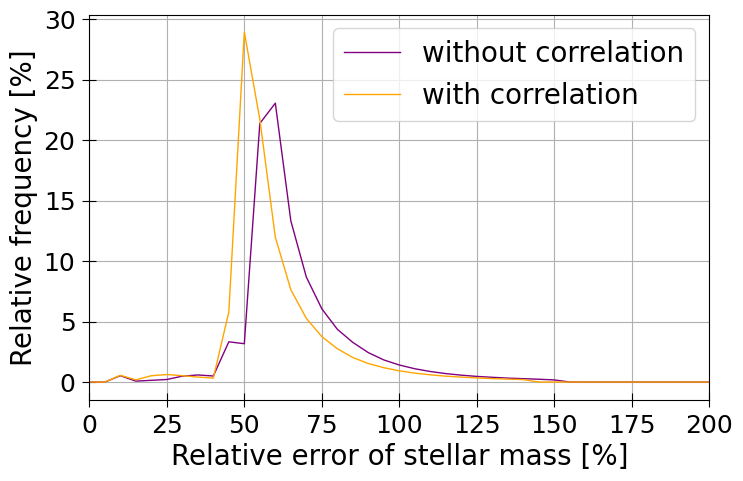

In [45]:
comp_hist( rel_err_M_Kettlety, rel_corr_err_M_Kettlety )
plt.xlim(0,200)

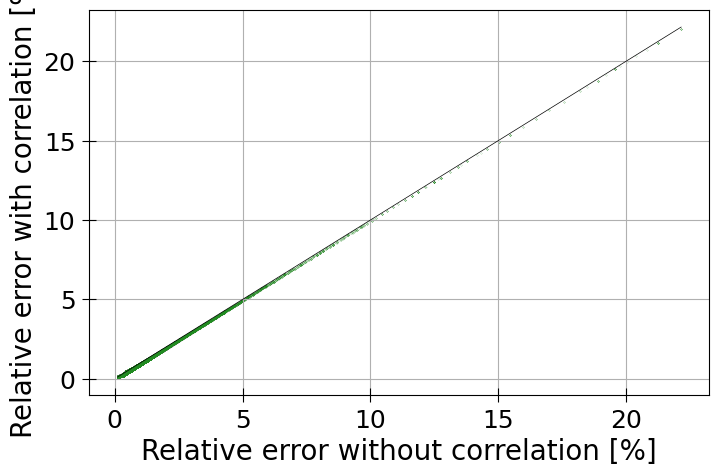

In [46]:
comp_plot( rel_err_M_Kettlety, rel_corr_err_M_Kettlety )

In [47]:
print( (rel_corr_err_M_Kettlety > 1).sum() )

929842


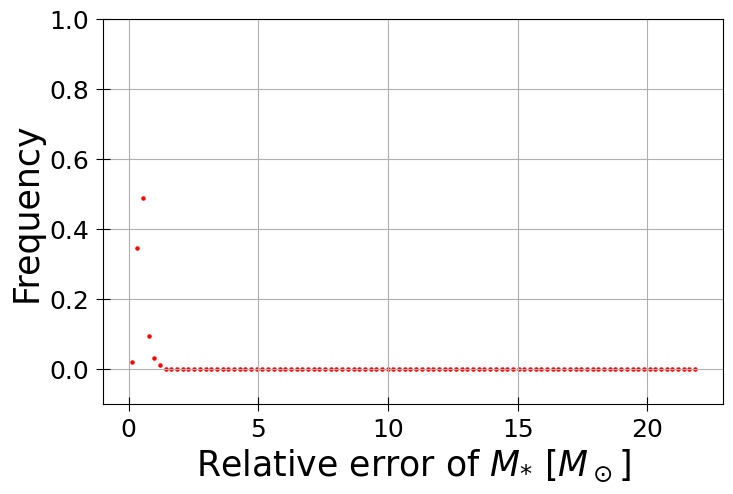

In [48]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.1, 1)

freq, bins = np.histogram( rel_corr_err_M_Kettlety,  bins=100 )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.W1)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

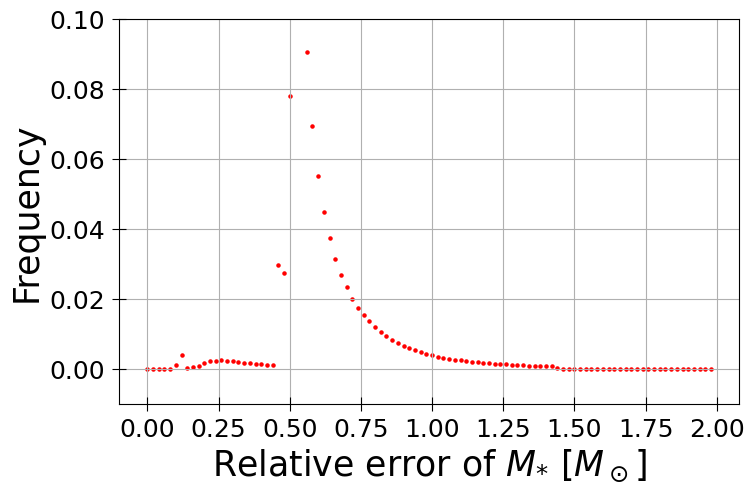

In [49]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.01, 0.1)

freq, bins = np.histogram( rel_corr_err_M_Kettlety,  bins=np.linspace(0,2,101) )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.W1)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

Mean and median error:

In [50]:
print( np.mean(rel_corr_err_M_Kettlety), np.median(rel_corr_err_M_Kettlety) )

0.6233071925913654 0.5735823272498299


In [51]:
print( np.mean(rel_err_M_Kettlety), np.median(rel_err_M_Kettlety) )

0.6903854487603329 0.6402496180851831


How many galaxies have stellar mass from this method?

In [52]:
len(M_Kettlety)

21747171

## Stellar mass estimation according to Jarrett's method:

Jarrett et al. 2013, AJ, 145, 6 (doi:10.1088/0004-6256/145/1/6)

$$\log(M_∗ (K_s )/L_{W1} )(M_\odot /L_\odot )
= −0.246(±0.027) − 2.100(±0.238)(W 1 − W 2)$$


In [53]:
# mass-to-light ratio
mtl = -0.246 - 2.1 *( M1 - M2 ) 
print( 'mass-to-light ratios:' )
print( mtl.iloc[0:5] )

# stellar masses according to Jarrett et al.:
M_Jarrett = L_W1*10**(mtl) 
print( '\nstellar masses according to Jarrett et al.:' )
print( M_Jarrett.iloc[0:5] )

mass-to-light ratios:
1   -0.473969
3   -0.184583
4   -0.406755
5   -0.272957
6   -0.085306
dtype: float64

stellar masses according to Jarrett et al.:
1    2.836963e+09
3    6.851917e+09
4    2.157553e+09
5    1.139543e+09
6    5.878716e+09
dtype: float64


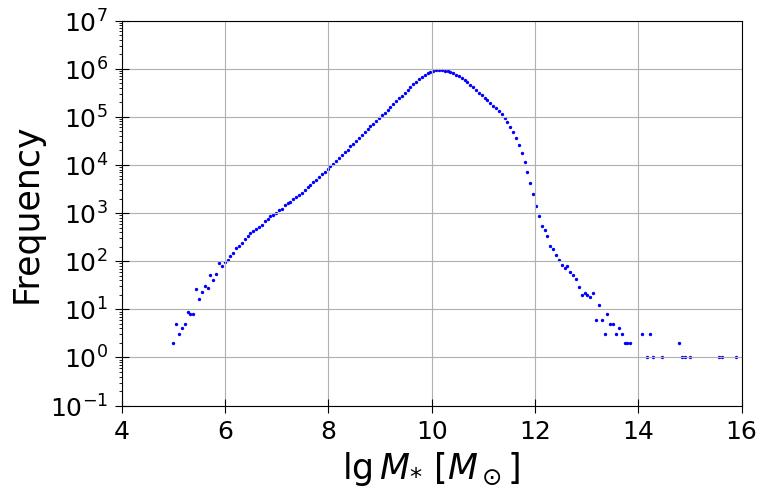

In [54]:
# form the figure:
hist_form()
plt.ylim( 1e-1, 1e7)
plt.xlim(4, 16)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Jarrett), np.linspace(5, 16, 200) )
plt.scatter( bins[:-1], freq,  marker = 'o', lw = 1, s = 2, color = 'blue' )
plt.grid()

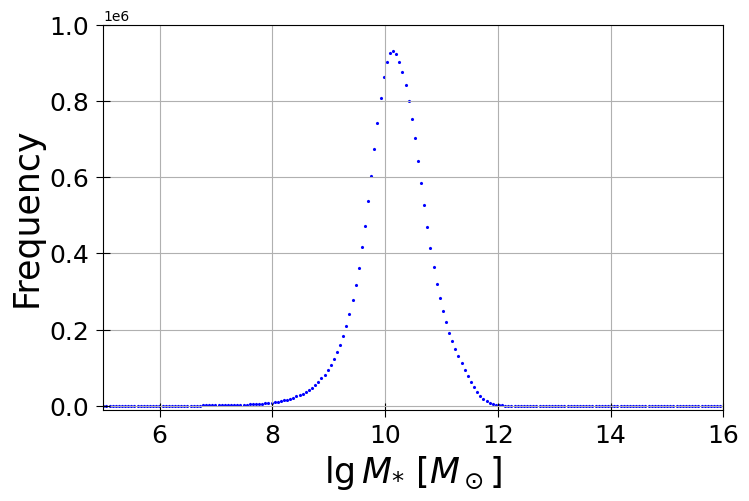

In [55]:
# form the figure:
hist_form()
plt.yscale( 'linear' )
plt.ylim(-1e4, 1e6)
plt.xlim(5, 16)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Jarrett), bins=np.linspace(5, 16, 200) )
plt.scatter( bins[:-1], freq,  marker = '*', lw = 1, s = 2, color = 'blue' )
plt.grid()

**Error estimation:**

The terms in the error propagation:

In [56]:
log = np.log(10)*M_Jarrett

Jarrett_der_a = log
Jarrett_der_b = (M1 - M2) * log
Jarrett_der_W1 = -2.5 * log
Jarrett_der_W2 = 2.1 * log
Jarrett_der_d = 2*M_Jarrett/data_new.dL
Jarrett_der_z = -0.5569 * log

Jarrett_der = [ Jarrett_der_a, Jarrett_der_b, Jarrett_der_W1, Jarrett_der_W2, Jarrett_der_d, Jarrett_der_z ]
Jarrett_var = [ 0.03, 0.2, (data_new.W1_err), (data_new.W2_err), (data_new.dL_err), (data_new.z_err)]
Jarrett_var_err = error_estimator_var( Jarrett_der, Jarrett_var, len(data_new), 6 )

Correlation coefficients:

$a$ and $b$ do not correlate with the other terms, therefore we have the same correlation coefficients as in the case of Cluver's method.

In [57]:
Jarrett_covar_err = error_estimator_covar(Jarrett_der[2:], Cluver_var, Cluver_corr_coef, len(data_new), 4 )

Jarrett_err = np.sqrt(Jarrett_var_err)
Jarrett_err_corr = np.sqrt(Jarrett_var_err + Jarrett_covar_err)

rel_err_M_Jarrett = np.sqrt(Jarrett_var_err)/M_Jarrett
rel_corr_err_M_Jarrett = np.sqrt(Jarrett_var_err + Jarrett_covar_err)/M_Jarrett

(0.0, 250.0)

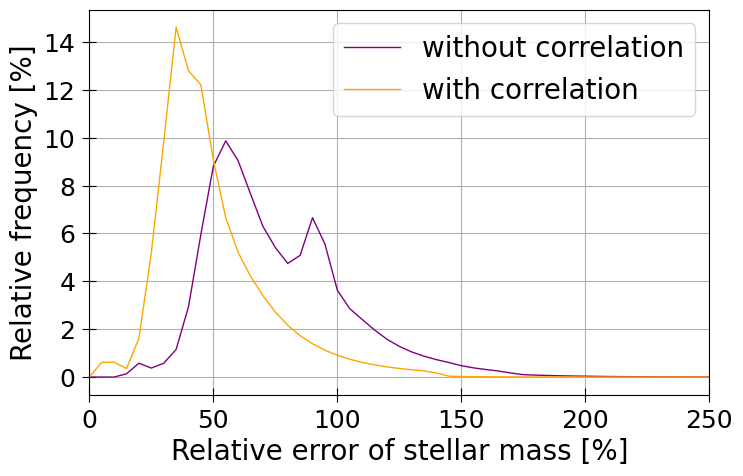

In [58]:
comp_hist( rel_err_M_Jarrett, rel_corr_err_M_Jarrett )
plt.xlim(0,250)

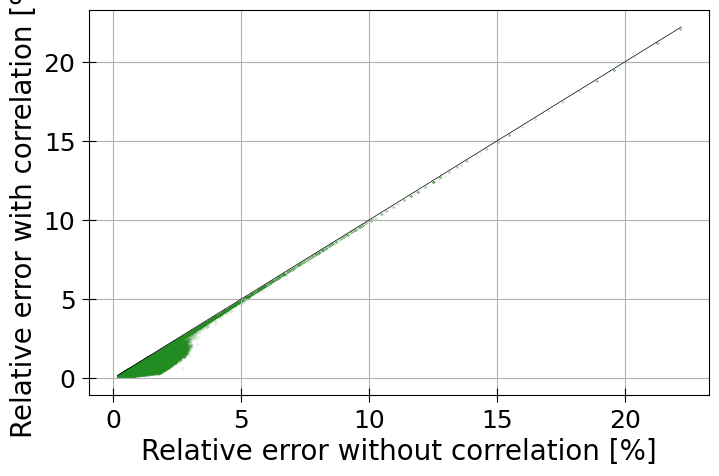

In [59]:
comp_plot( rel_err_M_Jarrett, rel_corr_err_M_Jarrett )

In [60]:
print( (rel_corr_err_M_Jarrett > 1).sum() )

965155


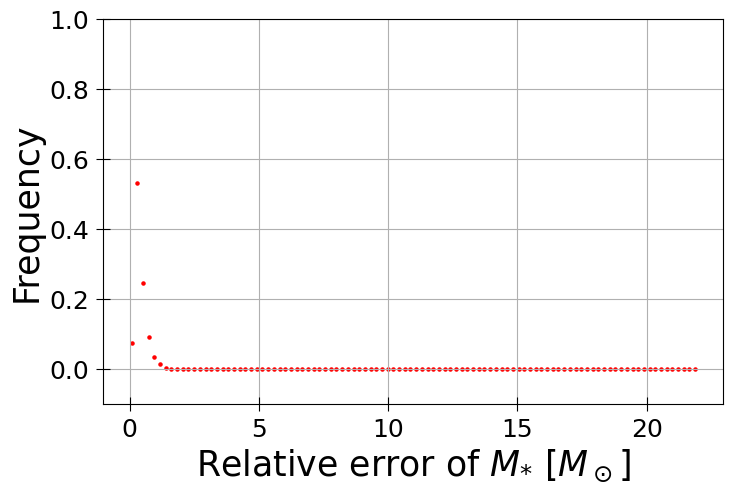

In [61]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.1, 1)

freq, bins = np.histogram( rel_corr_err_M_Jarrett,  bins=100 )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.W1)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

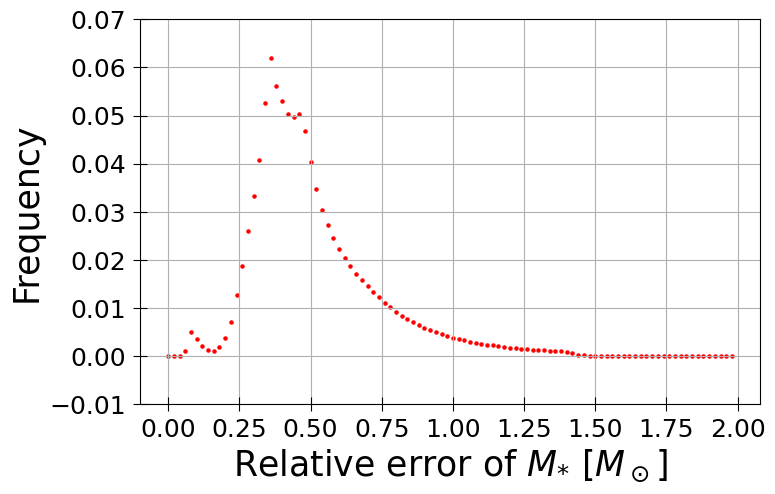

In [62]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.01, 0.07)

freq, bins = np.histogram( rel_corr_err_M_Jarrett,  bins=np.linspace(0,2,101) )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.W1)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

Mean and median error:

In [63]:
print( np.mean(rel_corr_err_M_Jarrett), np.median(rel_corr_err_M_Jarrett) )

0.5212794370142044 0.46732012708778825


In [64]:
print( np.mean(rel_err_M_Jarrett), np.median(rel_err_M_Jarrett) )

0.783642116748083 0.7217918585818036


How many galaxies have stellar mass from this method?

In [65]:
len(M_Jarrett)

21747171

## Cappellari's method:

Cappellari 2013. ( ApJL 778 L2, 2013, doi:10.1088/2041-8205/778/1/L2)

$$\lg M_∗ ≈ 10.58 − 0.44 (M_{K_s} + 23),$$

where $M_{K_s}$ is the absolute magnitude, but we have the apparent magnitude ($m$), so:

$$M_{K_s} = m+5-5 \lg d.$$

$$ M_* = 10^{10.583-0.445(M_{K_s}+23)}$$

### Query extinctions from the dustmap of Schlegel, Finkbeiner & Davis (1998)

In [66]:
#%%time
from __future__ import print_function
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery

# filter out galaxies which does not have a counterpart in the 2MASS
filt = data_new2["2MASS"].notnull() == True
glade_2MASS = data_new2[filt]
del data_new2 # freeing memory

ra = glade_2MASS['ra']
dec = glade_2MASS['dec']

coords = SkyCoord(ra, dec, unit='deg', frame='icrs')
sfd = SFDQuery()
ebv = sfd(coords)

In order to convert SFD values of E(B-V) to extinction, one should use the conversions provided in Table 6 of Schlafly
& Finkbeiner (2011).

According to Chung-Pei Ma, Jenny E. Greene, Nicholas McConnell, Ryan Janish, John P. Blakeslee, Jens Tho-
mas, and Jeremy D. Murphy. THE MASSIVE SURVEY. i. a VOLUME-LIMITED INTEGRAL-
FIELD SPECTROSCOPIC STUDY OF THE MOST MASSIVE EARLY-TYPE GALAXIES
WITHIN 108 mpc. The Astrophysical Journal, 795(2):158, oct 2014.:

"We compute the absolute K-band magnitudes using
$$M_K = K − 5 \lg D − 25 − 0.11 A_V,$$
where $K$ is given by k_m_ext, and $D$ is the distance in Mpc described in Sec 2.2. We use galactic extinction $A_V$ (Landolt V) from Schlafly & Finkbeiner (2011) and the reddening relation of Fitzpatrick (1999) with $R_V = A_V/E_{B−V} = 3.1$. The values of $K$, $A_V$, and $M_K$ for all galaxies are listed in Table 3. These K−band magnitudes
form the basis for our selection and are used to estimate stellar masses (§ 3.1)."

In Table 6 of Schlafly & Finkbeiner (2011) there is 2.742 in the row of Landolt V and in the column where $R_V$ is 3.1. So I will calculate the extinction as 
$$A_V = 2.742 \cdot E_{B-V},$$
here $E_{B-V}$ is ebv.

K-correction from Patrick's work:
$$K_K = −1.8178 z$$

In [67]:
ext = 2.742 * ebv 
glade_2MASS['ext'] = ext

### Calculating the absolute magnitude and the stellar mass

In [68]:
print( 'Absolute K_s magnitudes with extinction:' )
abs_m_Ks_E = glade_2MASS.k_m_ext - 5*np.log10(glade_2MASS.dL) - 25 - 0.11 * ext + 1.8178 * glade_2MASS.z
print( abs_m_Ks_E.iloc[0:5] )

print( '\nFiltration:  M_K_s < -21.5 mag')
glade_2MASS = glade_2MASS[abs_m_Ks_E < -21.5]
abs_m_Ks_E = abs_m_Ks_E[abs_m_Ks_E < -21.5]
print( abs_m_Ks_E.iloc[0:5] )

print( '\nStellar masses from K_s magnitudes:')
M_Cappellari= 10**( 10.58 - 0.44 * (abs_m_Ks_E + 23) )
print( M_Cappellari.iloc[0:5] )

Absolute K_s magnitudes with extinction:
1   -23.892704
3   -23.002352
5   -21.684772
6   -22.373963
7   -21.923539
dtype: float64

Filtration:  M_K_s < -21.5 mag
1   -23.892704
3   -23.002352
5   -21.684772
6   -22.373963
7   -21.923539
dtype: float64

Stellar masses from K_s magnitudes:
1    9.392690e+10
3    3.810964e+10
5    1.002997e+10
6    2.016247e+10
7    1.277488e+10
dtype: float64


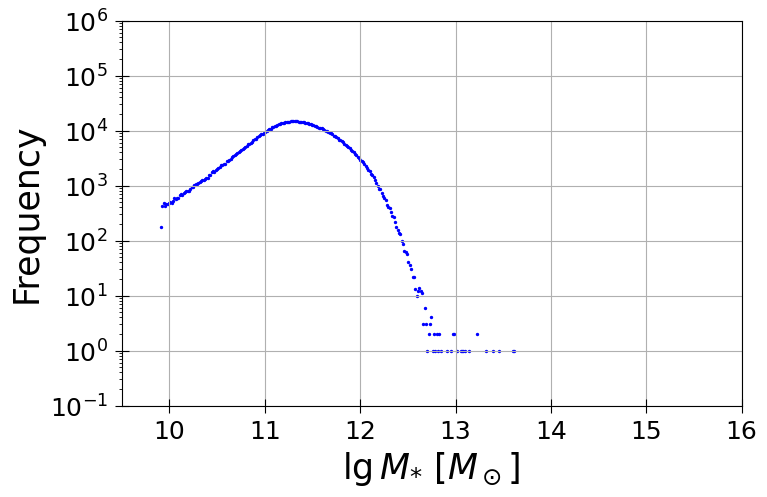

In [69]:
# form the figure:
hist_form()
plt.ylim( 1e-1, 1e6)
plt.xlim(9.5, 16)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Cappellari), np.linspace(9, 16, 500) )
plt.scatter( bins[:-1], freq,  marker = 'o', lw = 1, s = 2, color = 'blue' )
plt.grid()

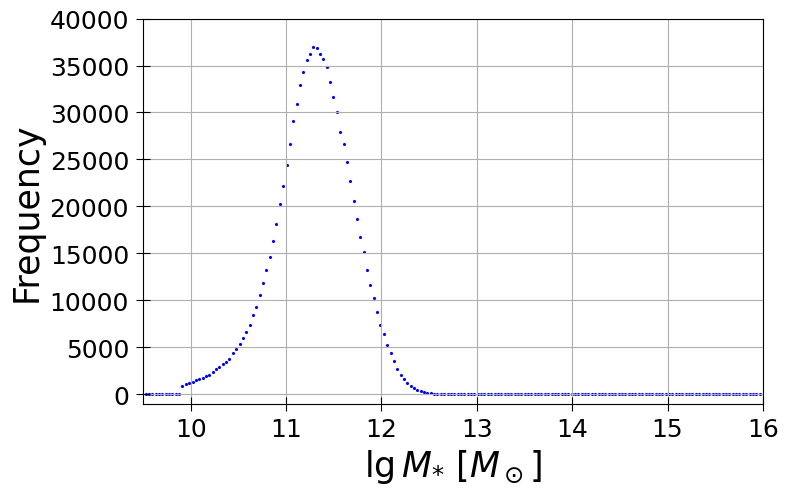

In [70]:
# form the figure:
hist_form()
plt.yscale( 'linear' )
plt.ylim(-1e3, 4e4)
plt.xlim(9.5, 16)

# make and plot histograms:
freq, bins = np.histogram( np.log10(M_Cappellari), bins=np.linspace(9, 16, 200) )
plt.scatter( bins[:-1], freq,  marker = '*', lw = 1, s = 2, color = 'blue' ) 
plt.grid()

**Error estimation**

If there is no magnitude error, I use the estimated errors from *Missing_error_estimation_rel.ipynb*.

In [71]:
glade_2MASS.fillna( {'k_msig_ext' : 0.02*glade_2MASS.k_m_ext}, inplace=True )
print( 'How many nan errors have remained?', np.sum(np.isnan(glade_2MASS['k_msig_ext'])) )

How many nan errors have remained? 0


In [72]:
glade_2MASS.fillna( {'dL_err':dle['edl']}, inplace=True )
print( 'How many nan errors have remained?', np.sum(np.isnan(glade_2MASS['dL_err'])) )

How many nan errors have remained? 0


The terms in the error propagation:

In [73]:
log = np.log(10)*M_Cappellari

Cappellari_der_a = log
Cappellari_der_b = -( abs_m_Ks_E + 23 )* log
Cappellari_der_m = -0.445 * log
Cappellari_der_d = 2.225 * M_Cappellari / glade_2MASS.dL
Cappellari_der_z = -0.808921 * log

Cappellari_der = [Cappellari_der_a, Cappellari_der_b, Cappellari_der_m, Cappellari_der_d, Cappellari_der_z]
Cappellari_var = [ 0.009, 0.009, (glade_2MASS.k_msig_ext), (glade_2MASS.dL_err), (glade_2MASS.z_err)]
Cappellari_var_err = error_estimator_var( Cappellari_der, Cappellari_var, len(glade_2MASS), 5 )

Correlation coefficients:

$a$ and $b$ do not correlate with the other terms.

In [74]:
corr_coef_m = [glade_2MASS.k_m_ext.corr(glade_2MASS.k_m_ext), 
                glade_2MASS.k_m_ext.corr(glade_2MASS.dL), glade_2MASS.k_m_ext.corr(glade_2MASS.z)]
corr_coef_d = [glade_2MASS.dL.corr(glade_2MASS.k_m_ext), 
                glade_2MASS.dL.corr(glade_2MASS.dL), glade_2MASS.dL.corr(glade_2MASS.z)]

Cappellari_corr_coef = [ corr_coef_m, corr_coef_d ]

In [75]:
Cappellari_covar_err = error_estimator_covar(Cappellari_der[2:], Cappellari_var[2:], Cappellari_corr_coef,
                                           len(glade_2MASS), 3)

Cappellari_err = np.sqrt(Cappellari_var_err)
Cappellari_err_corr = np.sqrt(Cappellari_var_err + Cappellari_covar_err)

rel_err_M_Cappellari = np.sqrt(Cappellari_var_err)/M_Cappellari
rel_corr_err_M_Cappellari = np.sqrt(Cappellari_var_err + Cappellari_covar_err)/M_Cappellari

(0.0, 250.0)

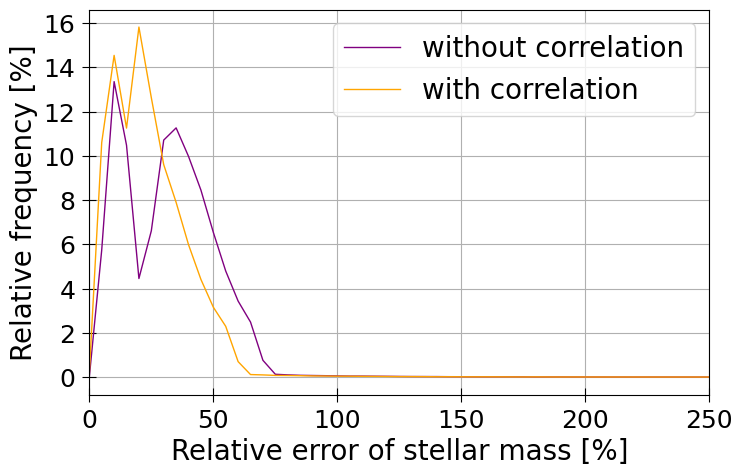

In [76]:
comp_hist( rel_err_M_Cappellari, rel_corr_err_M_Cappellari )
plt.xlim(0,250)

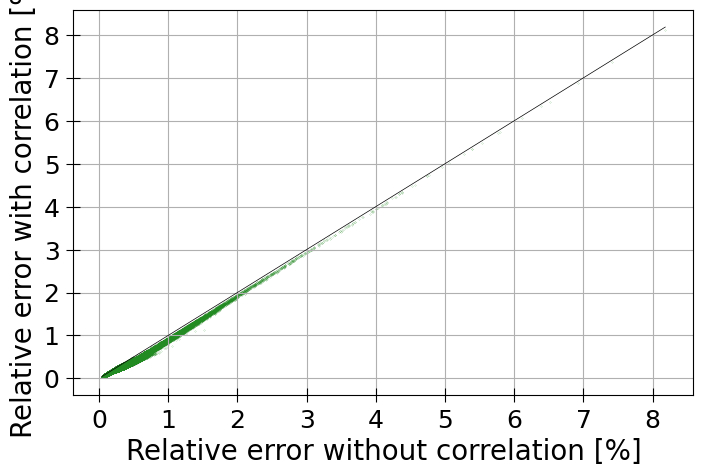

In [77]:
comp_plot( rel_err_M_Cappellari, rel_corr_err_M_Cappellari )

In [78]:
print( (rel_corr_err_M_Cappellari > 1).sum() )

3712


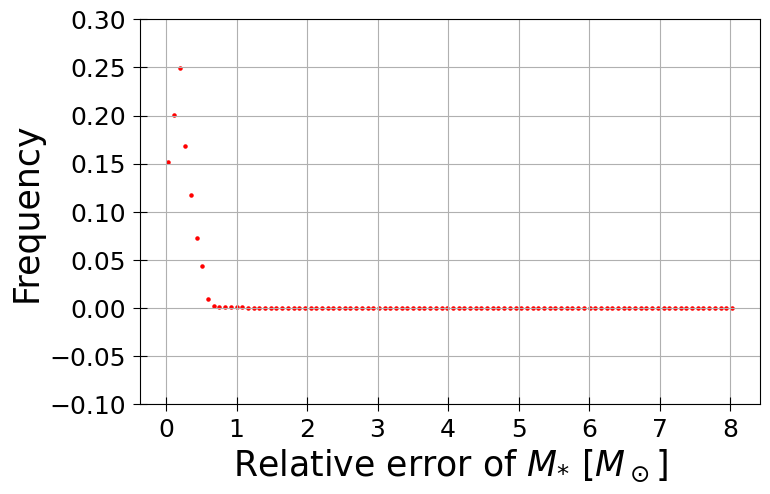

In [79]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.1, 0.3)

freq, bins = np.histogram( rel_corr_err_M_Cappellari,  bins=100 )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.k_m_ext)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

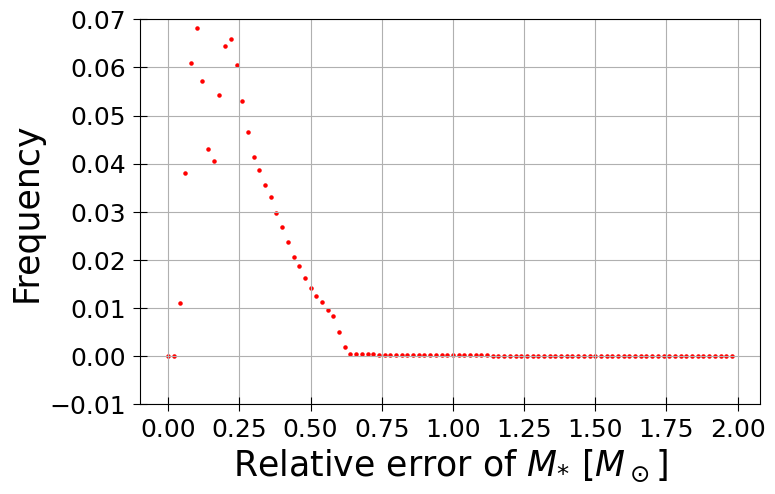

In [80]:
hist_form()
plt.xlabel( 'Relative error of $M_{*}$ [$M_\odot$]' )
plt.yscale( 'linear' )
plt.ylim(-0.01, 0.07)

freq, bins = np.histogram( rel_corr_err_M_Cappellari,  bins=np.linspace(0,2,101) )
plt.scatter( bins[:-1], freq/len(data_new[~np.isnan(data_new.k_m_ext)]),  marker = 'o', s = 5, color = 'red' )
plt.grid()

In [81]:
del data_new # freeing memory

Mean and median error:

In [82]:
print( np.mean(rel_corr_err_M_Cappellari), np.median(rel_corr_err_M_Cappellari) )

0.2672280080498003 0.2420453719455253


In [83]:
print( np.mean(rel_err_M_Cappellari), np.median(rel_err_M_Cappellari) )

0.3436873605697276 0.34408330095742495


How many galaxies have stellar mass from this method?

In [84]:
len(M_Cappellari)

990629

### Histogram to compare the four method

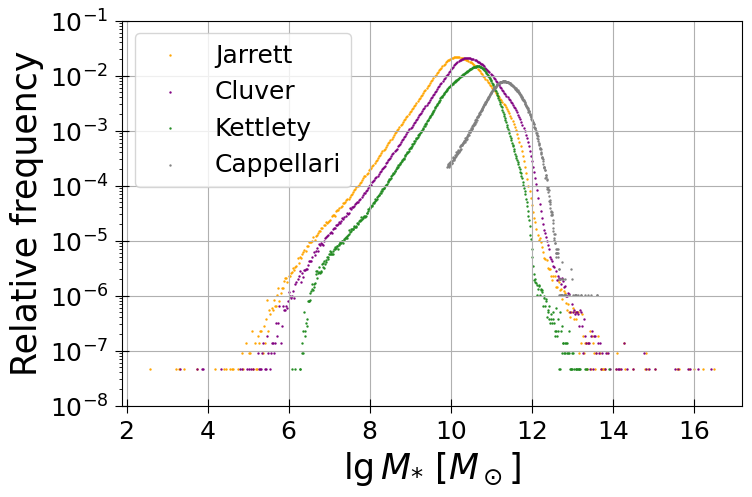

In [85]:
# form the figure:
hist_form()
plt.ylim(1e-8,1e-1)
plt.ylabel('Relative frequency')

# make and plot the histograms:
x = np.log10(M_Jarrett)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.scatter( bins[:-1], freq*(bins[1]-bins[0]),  marker = '.', s = 2, color = 'orange', 
            label = 'Jarrett' )

x = np.log10(M_Cluver)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.scatter( bins[:-1], freq*(bins[1]-bins[0]),  marker = '.', s = 2, color = 'purple',
            label = 'Cluver' )

x = np.log10(M_Kettlety)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.scatter( bins[:-1], freq*(bins[1]-bins[0]),  marker = '.', s = 2, color = 'forestgreen',
            label = 'Kettlety' ) 

x = np.log10(M_Cappellari)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.scatter( bins[:-1], freq*(bins[1]-bins[0]),  marker = '.', s = 2, color = 'grey',
            label = 'Cappellari' )

plt.legend( fontsize = 18, loc = 'upper left' ) # set legend
plt.grid()
#plt.savefig( '4histogram.eps', format = 'eps' ) # save the figure

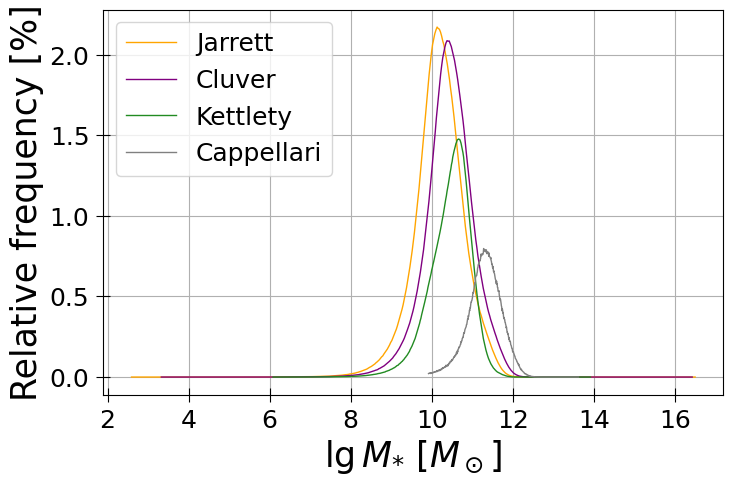

In [86]:
# form the figure:
hist_form()
plt.yscale('linear')
plt.ylabel('Relative frequency [%]')
plt.autoscale()

# make and plot the histograms:
x = np.log10(M_Jarrett)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]), lw = 1, color = 'orange', 
            label = 'Jarrett' )

x = np.log10(M_Cluver)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]), lw = 1, color = 'purple',
            label = 'Cluver' )

x = np.log10(M_Kettlety)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]), lw = 1, color = 'forestgreen',
            label = 'Kettlety' ) 

x = np.log10(M_Cappellari)
freq, bins = np.histogram( x, bins=np.linspace(np.min(x), np.max(x), 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]),  lw = 1, color = 'grey',
            label = 'Cappellari' )

plt.legend( fontsize = 18, loc = 'upper left' ) # set legend
plt.grid()
#plt.savefig( '4histogram.eps', format = 'eps' ) # save the figure

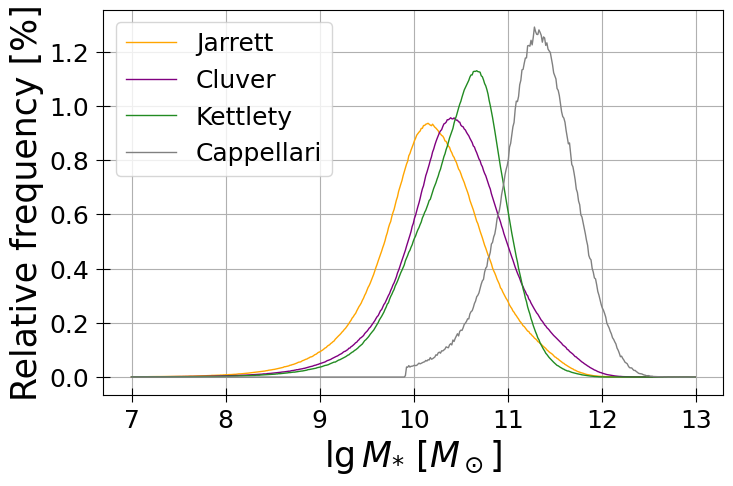

In [87]:
# form the figure:
hist_form()
plt.yscale('linear')
plt.ylabel('Relative frequency [%]')
plt.autoscale()

# make and plot the histograms:
x = np.log10(M_Jarrett)
freq, bins = np.histogram( x, bins=np.linspace(7, 13, 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]), lw = 1, color = 'orange', 
            label = 'Jarrett' )

x = np.log10(M_Cluver)
freq, bins = np.histogram( x, bins=np.linspace(7, 13, 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]), lw = 1, color = 'purple',
            label = 'Cluver' )

x = np.log10(M_Kettlety)
freq, bins = np.histogram( x, bins=np.linspace(7, 13, 500), density = True ) 
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]), lw = 1, color = 'forestgreen',
            label = 'Kettlety' ) 

x = np.log10(M_Cappellari)
freq, bins = np.histogram( x, bins=np.linspace(7, 13, 500), density = True )
plt.plot( bins[:-1], freq*100*(bins[1]-bins[0]),  lw = 1, color = 'grey',
            label = 'Cappellari' )

plt.legend( fontsize = 18, loc = 'upper left' ) # set legend
plt.grid()
#plt.savefig( '4histogram.eps', format = 'eps' ) # save the figure

## Writting the stellar masses to the dataframe

In [88]:
data['SMass_Cluver'] = M_Cluver 
data['SMass_Kettlety'] = M_Kettlety
data['SMass_Jarrett'] = M_Jarrett
data['SMass_Cappellari'] =  M_Cappellari
data['err_SMass_Kettlety'] = rel_corr_err_M_Kettlety
data['err_SMass_Cappellari'] = rel_corr_err_M_Cappellari
data['err_SMass_Jarrett'] = rel_corr_err_M_Jarrett
data['err_SMass_Cluver'] = rel_corr_err_M_Cluver

print( 'Data with stellar masses:')
data

Data with stellar masses:


,ID,2MASS,wiseX,type,ra,dec,W1,W1_err,W2,W2_err,...,k_m_ext,k_msig_ext,SMass_Cluver,SMass_Kettlety,SMass_Jarrett,SMass_Cappellari,err_SMass_Kettlety,err_SMass_Cappellari,err_SMass_Jarrett,err_SMass_Cluver
0,1,12505314+4107125,J125053.14+410712.7,G,192.721451,41.120152,5.611000,NaN,6.120000,NaN,...,5.106,0.016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,12352642+1429467,J123526.45+142946.9,G,188.860123,14.496320,9.416000,NaN,9.306000,NaN,...,7.115,0.031,4.831161e+09,3.357468e+09,2.836963e+09,9.392690e+10,0.617696,0.443084,0.448000,0.434241
2,3,17492651+7008396,J174926.45+700840.8,G,267.360474,70.144341,10.180000,NaN,10.102000,NaN,...,7.296,0.021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,12280389+0948130,J122803.90+094813.3,G,187.016220,9.803620,8.476000,NaN,8.504000,NaN,...,7.294,0.024,1.116137e+10,6.801542e+09,6.851917e+09,3.810964e+10,0.446961,0.470877,0.461529,0.451584
4,5,NaN,J122928.05+084500.8,G,187.367000,8.749890,9.784000,NaN,9.706000,NaN,...,NaN,NaN,3.636457e+09,2.187268e+09,2.157553e+09,NaN,0.635694,NaN,0.473573,0.461438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23181753,23181754,NaN,NaN,Q,359.999118,28.954734,17.728901,NaN,16.535843,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23181754,23181755,NaN,NaN,Q,359.999303,34.720842,16.933657,NaN,15.875454,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23181755,23181756,NaN,NaN,Q,359.999615,3.268586,14.833991,NaN,13.702355,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23181756,23181757,NaN,NaN,Q,359.999759,20.721079,16.979166,NaN,16.091722,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
del M_Cluver
del M_Jarrett
del M_Kettlety
del M_Kettlety_active
del M_Kettlety_passive
del M_Cappellari
del rel_corr_err_M_Cluver
del rel_corr_err_M_Jarrett
del rel_corr_err_M_Kettlety
del rel_corr_err_M_Kettlety_active
del rel_corr_err_M_Kettlety_passive
del rel_corr_err_M_Cappellari
del rel_err_M_Cluver
del rel_err_M_Jarrett
del rel_err_M_Kettlety
del rel_err_M_Kettlety_active
del rel_err_M_Kettlety_passive
del rel_err_M_Cappellari

In [91]:
# Filtration the galaxies which have stellar mass from both method:
data_mass = copy.deepcopy( data[ ~np.isnan(data.SMass_Cappellari) ] )
print('Galaxies with stellar mass from Cappelari\'s method:', data_mass.shape[0])
data_mass = data_mass[ ~np.isnan(data_mass.SMass_Cluver) ]
print('Galaxies with stellar mass from both method:', data_mass.shape[0])
#print( data_mass )
# write out data
f_out = 'sm_both.txt'
data_mass.to_csv( f_out, sep = '\t', index = False )
print( 'both methods: ', f_out )

Galaxies with stellar mass from Cappelari's method: 990629
Galaxies with stellar mass from both method: 959485
both methods:  sm_both.txt


In [92]:
del data_mass

In [93]:
# Filtration the galaxies which have stellar mass from at least one method:
data_total = data[ data.type != 'Q' ] 

In [94]:
del data

In [ ]:
data_total1 = data_total[ ~np.isnan(data_total.SMass_Kettlety) ]
data_total2 = data_total[ np.isnan(data_total.SMass_Kettlety) & ~np.isnan(data_total.SMass_Cappellari)]
data_total = pd.concat( [data_total1, data_total2], axis = 0, sort = False )
print('Galaxies with stellar mass from at least one method:', data_total.shape[0])
# write out data
f_out = 'total_sm.txt'
data_total.to_csv( f_out, sep = '\t', index = False )
print( 'at least one method: ', f_out )

Galaxies with stellar mass from at least one method: 21778315
